<a href="https://www.kaggle.com/code/samratrm/kmeans-mall-customer-segmentation?scriptVersionId=340798993" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🛒 Customer Segmentation via K-Means Clustering

## 🎯 Executive Summary & Objectives

The goal of this project is to perform unsupervised customer segmentation on mall shopper data using **K-Means Clustering** to identify distinct buyer personas and unlock actionable marketing strategies. 

By analyzing demographics (**Age**, **Gender**) and behavioral metrics (**Annual Income**, **Spending Score**), we transform raw customer data into targeted strategic insights.


**AI Disclosure:** I used AI to help code the boilerplate, build the complex plots, and polish the summaries, but I have personally read, verified, and take responsibility for everything here.


### Key Objectives:
1. **Exploratory Data Analysis (EDA):** Identify distribution patterns, feature correlations, and natural spatial groupings across customer metrics.
2. **Feature Preprocessing & Pipeline Building:** Construct a scikit-learn preprocessing pipeline using standard scaling and categorical encoding to prepare data for distance-based algorithms.
3. **Optimal Cluster Selection ($K$):** Validate the best number of clusters using both **Inertia (Elbow Method)** and **Silhouette Analysis**, cross-checked against **2D t-SNE** and **3D feature projections**.
4. **Segment Profiling & Business Actionability:** Characterize each cluster profile to deliver concrete, revenue-driving recommendations tailored to each customer segment.

## Data Understanding

In [55]:
import numpy as np
import pandas as pd
import os
import kagglehub
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv("/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv")
df.head()

/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [56]:
df.shape

(200, 5)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [58]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Data Cleaning 

In [59]:
df = df.rename(columns={
    "Annual Income (k$)" : "annual_income",
    "Spending Score (1-100)" : "spending_score",
    "Gender" : "gender",
    "Age" : "age"
})

df = df.drop('CustomerID', axis=1)

df.shape

(200, 4)

In [60]:
df.isna().sum()

gender            0
age               0
annual_income     0
spending_score    0
dtype: int64

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
cat = df.select_dtypes(include=["category","object"]).columns.to_list()
df_tsne = pd.get_dummies(df, columns=cat).astype(int)
df_tsne.columns

Index(['age', 'annual_income', 'spending_score', 'gender_Female',
       'gender_Male'],
      dtype='object')

## Data Visualization

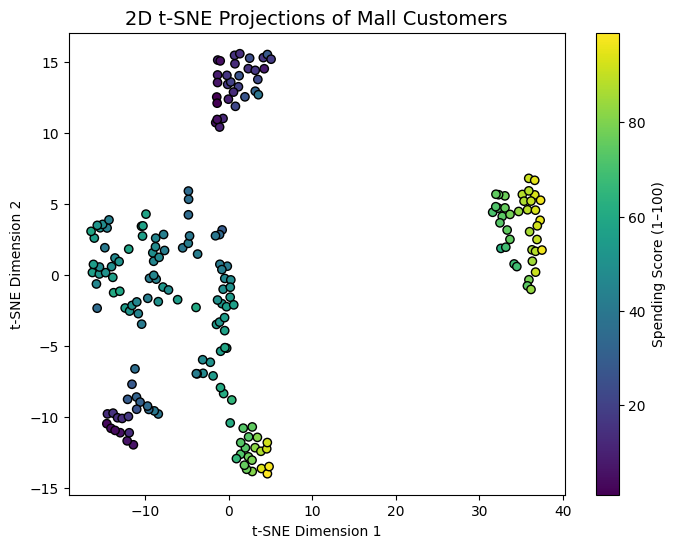

In [63]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=20, random_state=42, max_iter=1000)
X_embedded = tsne.fit_transform(df_tsne)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_embedded[:, 0],
    X_embedded[:, 1],
    cmap="viridis",
    edgecolors="k",
    c=df_tsne["spending_score"],
)

cbar = plt.colorbar(scatter)
cbar.set_label("Spending Score (1–100)")

plt.title("2D t-SNE Projections of Mall Customers", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.show()

In [64]:
import plotly.express as px
from sklearn.preprocessing import StandardScaler

# 1. Select and scale the numeric features
numeric_cols = ["annual_income", "spending_score", "age"]
scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# 2. Create 3D Scatter Plot
fig = px.scatter_3d(
    df_scaled,
    x="annual_income",
    y="spending_score",
    z="age",
    color="gender",
    hover_data={
        "annual_income": ":.2f",
        "spending_score": ":.2f",
        "age": ":.2f"
    },
    title="3D Plot: Scaled Annual Income, Spending Score, and Age",
    labels={
        "annual_income": "Annual Income (Scaled)",
        "spending_score": "Spending Score (Scaled)",
        "age": "Age (Scaled)",
        "gender": "Gender"
    },
    template="plotly_dark",
    width=900,
    height=700
)

fig.show()

## Univariate and Bivariate Analysis 

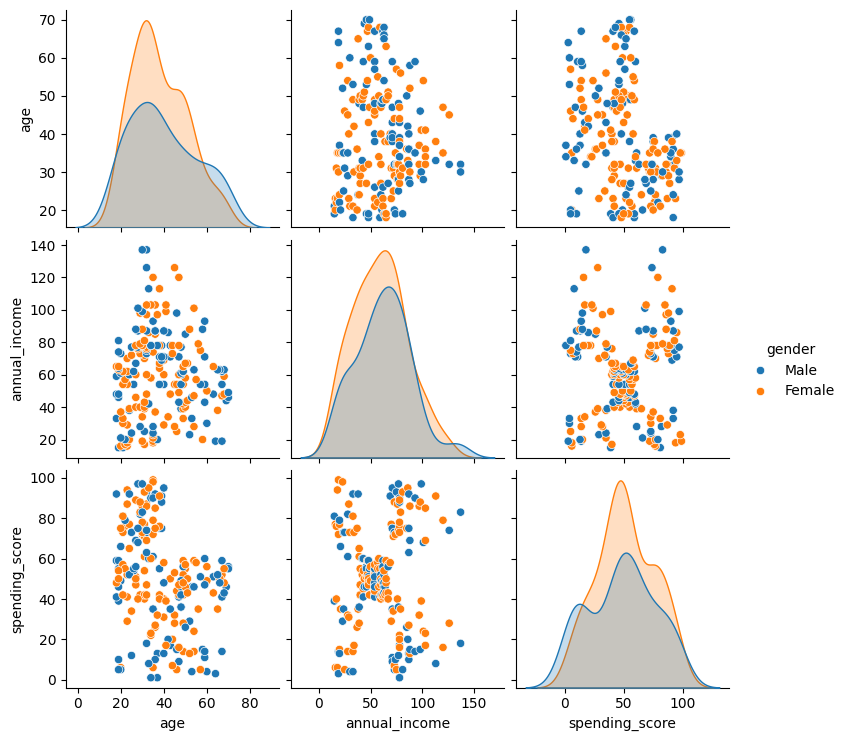

In [65]:
sns.pairplot(df, hue="gender")
plt.show()

In [66]:
num_feats = df.select_dtypes("number").columns.to_list()
cat_feats = df.select_dtypes(exclude=["number"]).columns.to_list()
num_feats, cat_feats

(['age', 'annual_income', 'spending_score'], ['gender'])

## Correlation Analysis

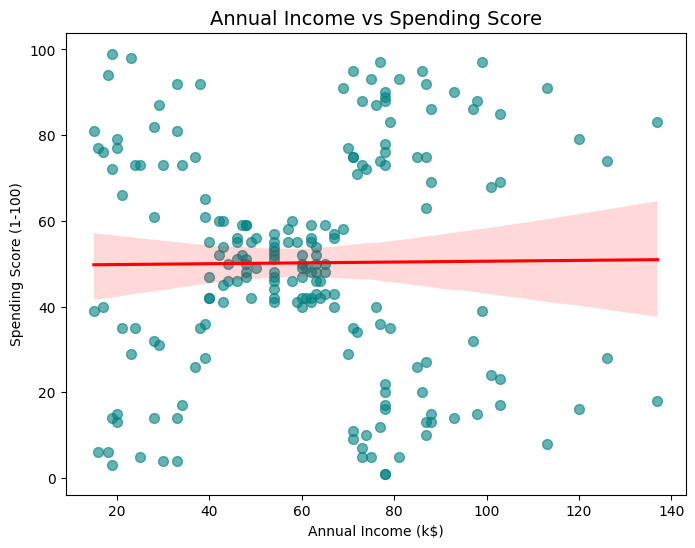

In [67]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df, 
    x="annual_income", 
    y="spending_score", 
    color="teal", 
    scatter_kws={"alpha": 0.6, "s": 50},
    line_kws={"color": "red"}
)

plt.title("Annual Income vs Spending Score", fontsize=14)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

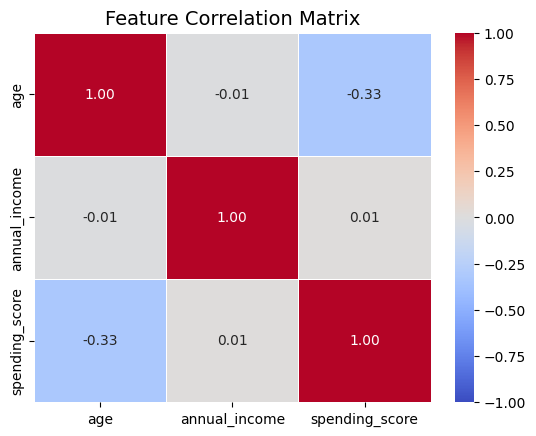

In [68]:
corr_matrix = df[num_feats].corr(method="pearson")

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidth=0.5)
plt.title("Feature Correlation Matrix", fontsize=14)
plt.show()


**EDA Summary — Mall Customer Segmentation**

*Data:* 200 rows, 4 usable features after dropping `CustomerID` (an identifier, carries no customer information and would dominate any distance calculation). No missing values, no duplicates.

*Univariate:*
- `age`: 18–70, mean 38.9, median 36 Which indicates mild right skew.
- `annual_income`: 15–137 k$, median 61.5, 75th pct 78 indicating a right tail and a handful of high earners sit far from the mass.
- `spending_score`: 1–99, mean 50.2, median 50.0 which means a near-uniform. It's a constructed index, not organic behaviour, so no transformation needed.
- Spread: income std 26.3, spending std 25.8, age std 14.0.

*Correlation:* `annual_income` vs `spending_score` ≈ 0. This is **not** evidence of no structure. Pearson fits one global line; here high earners split into heavy spenders and non-spenders, and the two opposing tendencies cancel. Correlation is blind to local cluster structure.

*Bivariate (income vs spending):* five distinct point clouds separated by empty space — low/low, low/high, mid/mid, high/low, high/high. Gaps at income ≈ 65–70 and at spending ≈ 40–60 (the spending gap appears only at the income extremes). The fitted regression line runs flat through the empty middle, describing no real customer.

*Conclusions carried into modelling:*
1. **Hypothesis: k = 5**, from the visible structure above.
2. **Primary feature pair:** `annual_income`, `spending_score` — the segments live here. `age` and `gender` reserved for profiling, or a second variant of the model.
3. **Scaling:** income and spending already have near-identical spread, so standardising changes little between those two. It becomes necessary the moment `age` (std 14) joins them. Scale anyway as good practice.
4. **Outliers:** the high-income tail is real customer behaviour, not error — keep it, but expect KMeans centroids to be pulled by it, since KMeans minimises *squared* distance.


## Preprocessing & Pipeline Building 

In [69]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df_encoded = pd.get_dummies(df, columns=["gender"], drop_first=True).astype(int)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.33690046, 0.26230645, 0.23260639, 0.16818671])

In [70]:
num_feats, cat_feats

(['age', 'annual_income', 'spending_score'], ['gender'])

In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans 

preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), num_feats),
        ("cat", OneHotEncoder(drop="first"), cat_feats)
    ]
)

feature_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor)
    # ("pca", PCA(n_components=0.9, random_state=42))
])

X_prepared = feature_pipeline.fit_transform(df)
X_prepared[:5]

array([[-1.42456879, -1.73899919, -0.43480148,  1.        ],
       [-1.28103541, -1.73899919,  1.19570407,  1.        ],
       [-1.3528021 , -1.70082976, -1.71591298,  0.        ],
       [-1.13750203, -1.70082976,  1.04041783,  0.        ],
       [-0.56336851, -1.66266033, -0.39597992,  0.        ]])

## K-means Clustering

In [72]:
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = [] 

K = range(1,11)
for k in K:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=100, n_init=10, tol=1e-4, verbose=0, random_state=42)
    model =  kmeans.fit(X_prepared)
    inertia.append(model.inertia_)

    if k  > 1:
        labels = model.predict(X_prepared)
        score = silhouette_score(X_prepared, labels)
        silhouette_scores.append(score)

fig = px.line(
    x=list(K),
    y=inertia,
    markers=True,
    title="Elbow Method for Optimal K",
    labels={"x": "Number of Clusters (K)", "y": "Inertia (WCSS)"},
    template="plotly_dark",
)

fig.update_traces(line=dict(color="#FF8C00", width=2.5), marker=dict(size=8))
fig.show()

In [73]:
fig = px.line(
    x=list(K[1:]),
    y=silhouette_scores,
    markers=True,
    title="Silhouette Analysis for Optimal K",
    labels={"x": "Number of Clusters (K)", "y": "Silhouette Score"},
    template="plotly_dark",
)

fig.update_traces(line=dict(color="#FF8C00", width=2.5), marker=dict(size=8))
fig.show()


**Model Selection Note ($K = 5$):**
* **Silhouette Analysis:** While $K = 6$ yields a marginally higher score ($\approx 0.43$), $K = 5$ performs nearly identically ($\Delta \text{score} \approx 0.01$) without over-segmenting the dataset.
* **Visual Validation:** 2D t-SNE projections show 5 clear, distinct cluster groupings.
* **Business Context:** $K = 6$ splits low-income, low-spending customers into two redundant "low engagement" sub-groups. $K = 5$ merges them into a single coherent segment, preserving better domain interpretability.
* **Decision:** Proceeding with **$K = 5$** for final segment profiling.


In [74]:
import plotly.graph_objects as go

best_k = 5
kmeans = KMeans(n_clusters=best_k, random_state=42, init="k-means++")
labels_ = kmeans.fit_predict(X_prepared)

# Update scaled dataframe
df_scaled["label"] = labels_

# Extract Centroids
centroids = kmeans.cluster_centers_
centroids_df = pd.DataFrame(
    centroids,
    columns=["age", "annual_income", "spending_score", "gender_Male"],
)

fig = go.Figure()

for cluster in range(best_k):
    cluster_data = df_scaled[df_scaled["label"] == cluster]
    fig.add_trace(
        go.Scatter3d(
            x=cluster_data["annual_income"],
            y=cluster_data["spending_score"],
            z=cluster_data["age"],
            mode="markers",
            name=f"Cluster {cluster}",
            marker=dict(size=5, opacity=0.8),
            customdata=cluster_data[["annual_income", "spending_score", "age"]],
            hovertemplate="Annual Income: %{customdata[0]:.2f}<br>Spending Score: %{customdata[1]:.2f}<br>Age: %{customdata[2]:.2f}<extra></extra>",
        )
    )

fig.add_trace(
    go.Scatter3d(
        x=centroids_df["annual_income"],
        y=centroids_df["spending_score"],
        z=centroids_df["age"],
        mode="markers+text",
        name="Centroids",
        text=[f"Centroid {i}" for i in range(best_k)],
        textposition="top center",
        marker=dict(
            size=10,
            color="yellow",
            symbol="circle",
            line=dict(color="black", width=1),
        ),
    )
)

fig.update_layout(
    title="3D Plot: Scaled Annual Income, Spending Score, and Age with Centroids",
    scene=dict(
        xaxis_title="Annual Income (Scaled)",
        yaxis_title="Spending Score (Scaled)",
        zaxis_title="Age (Scaled)",
    ),
    template="plotly_dark",
    width=900,
    height=700,
)

fig.show()

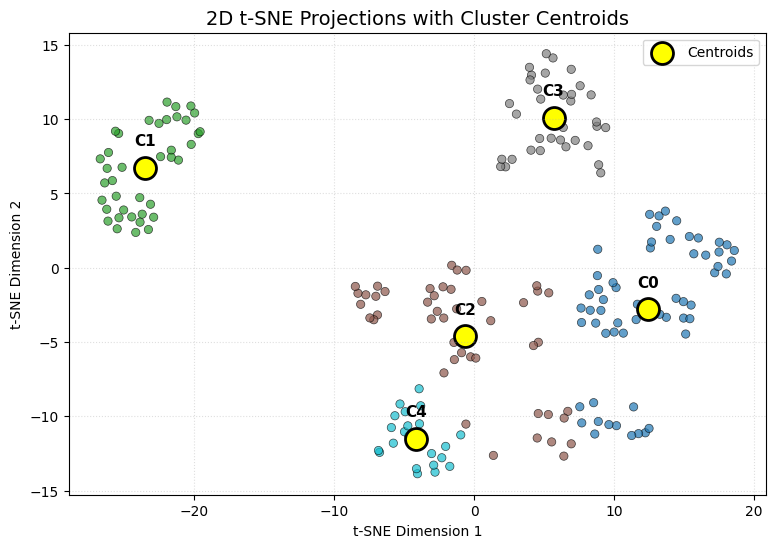

In [75]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

df["label"] = labels_

# Fit t-SNE on your prepared features
tsne = TSNE(n_components=2, perplexity=20, random_state=42, max_iter=1000)
X_embedded = tsne.fit_transform(X_prepared)

# Calculate 2D centroid locations by averaging t-SNE coordinates for each cluster
centroids_2d = np.array(
    [X_embedded[df["label"] == k].mean(axis=0) for k in range(best_k)]
)

# Plot t-SNE scatter plot
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_embedded[:, 0],
    X_embedded[:, 1],
    c=df["label"],
    cmap="tab10",
    alpha=0.7,
    edgecolors="k",
    linewidths=0.5,
)

# Overlay Centroids as Yellow Spheres / Circles
plt.scatter(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    s=250,
    c="yellow",
    marker="o",
    edgecolors="black",
    linewidths=2,
    label="Centroids",
)

# Annotate centroid labels
for i, (x, y) in enumerate(centroids_2d):
    plt.text(
        x,
        y + 1.5,
        f"C{i}",
        fontsize=11,
        weight="bold",
        ha="center",
        color="black",
    )

plt.title("2D t-SNE Projections with Cluster Centroids", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.4)
plt.show()

## Model Evaluation

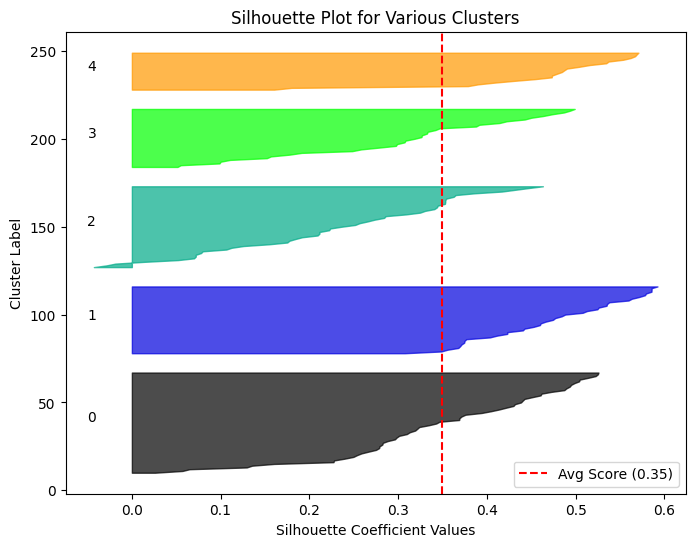

In [79]:
from sklearn.metrics import silhouette_samples

sample_silhouette_values = silhouette_samples(X_prepared, labels_)
avg_score = silhouette_score(X_prepared, labels_)

plt.figure(figsize=(8, 6))
y_lower = 10

for i in range(best_k):
    ith_cluster_scores = sample_silhouette_values[labels_ == i]
    ith_cluster_scores.sort()

    size_cluster_i = ith_cluster_scores.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / best_k)
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_scores,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10  # 10 points space between clusters

plt.axvline(
    x=avg_score, color="red", linestyle="--", label=f"Avg Score ({avg_score:.2f})"
)
plt.title("Silhouette Plot for Various Clusters")
plt.xlabel("Silhouette Coefficient Values")
plt.ylabel("Cluster Label")
plt.legend()
plt.show()

#### Silhouette Sample Summary:

* **Clusters 0 & 1 are strongest:** They exhibit the highest density and cohesion, with silhouette values reaching up to 0.59 (well above the overall mean).

* **Cluster 2 is diffuse:** It is the weakest cluster, showing a wide, gradual spread from ~0 to 0.46 rather than a tight, solid core.
* **Minor boundary overlap:** Cluster 2 has a tiny negative tail representing expected boundary overlap; this is minor and does not warrant changing $K$.
* **Overall score shift (0.42 → 0.35):** The average score dropped after removing PCA because the raw binary `gender_Male` column introduces discrete distance noise into Euclidean calculations.

In [77]:
summary_stats = (
    df["label"]
    .value_counts(normalize=True)
    .to_frame(name="percentage")
    .assign(count=df["label"].value_counts(), percentage=lambda x: x["percentage"] * 100)
)

feature_means = df.groupby("label").agg(
    {
        "age": "mean",
        "annual_income": "mean",
        "spending_score": "mean",
        "gender": lambda x: (x == "Female").mean() * 100,
    }
).rename(columns={"gender": "female_pct"})

combined_result = summary_stats.join(feature_means).reset_index()

combined_result = combined_result[
    ["label", "count", "percentage", "age", "annual_income", "spending_score", "female_pct"]
]

(
    combined_result.style
    .background_gradient(cmap="Greens", subset=["annual_income", "spending_score"])
    .background_gradient(cmap="Oranges", subset=["count", "percentage"])
    .background_gradient(cmap="Blues", subset=["age"])
    .background_gradient(cmap="Purples", subset=["female_pct"])
    .format({
        "count": "{:d}",
        "percentage": "{:.1f}%",
        "age": "{:.1f}",
        "annual_income": "${:.1f}k",
        "spending_score": "{:.1f}",
        "female_pct": "{:.1f}%"
    })
    .hide(axis="index")
)

label,count,percentage,age,annual_income,spending_score,female_pct
0,58,29.0%,55.6,$48.5k,41.8,56.9%
2,47,23.5%,28.0,$50.0k,44.6,66.0%
1,39,19.5%,32.7,$86.5k,82.1,53.8%
3,34,17.0%,41.3,$88.5k,16.8,41.2%
4,22,11.0%,25.3,$25.7k,79.4,59.1%


## Cluster Profiling & Segment Naming

### Cluster 0 — `mature_mainstream` (n = 47, 23.5% of base)
**Profile:**
- Age: 55.6 (above mean 38.9)
- Income: $54.4k (vs mean 60.6), Spending: 48.9 (vs mean 50.2)
- Gender: 57.4% female (close to mean 56.0%)

**Why this name:** Older cohort with average income and moderate spending habits; stable, core shoppers who show predictable baseline engagement.

**Action:** Focus on customer retention, clear store navigation, loyalty perks, and value-oriented brand offerings.



### Cluster 1 — `elite` (n = 40, 20.0% of base)
**Profile:**
- Age: 32.9 (below mean 38.9)
- Income: $86.1k (well above mean 60.6), Spending: 81.5 (well above mean 50.2)
- Gender: 55.0% female (close to mean 56.0%)

**Why this name:** Younger, high-income individuals who actively spend at premium levels.

**Action:** Target with VIP loyalty programs, high-end product drops, exclusive event invitations, and personalized luxury offers.



### Cluster 2 — `young_aspirational` (n = 54, 27.0% of base)
**Profile:**
- Age: 25.2 (well below mean 38.9)
- Income: $41.1k (below mean 60.6), Spending: 62.2 (above mean 50.2)
- Gender: 59.3% female (close to mean 56.0%)

**Why this name:** Youngest demographic spending disproportionately high relative to their lower income level.

**Action:** Engage through trend-driven marketing, budget-friendly financing/buy-now-pay-later, seasonal discounts, and social media campaigns.



### Cluster 3 — `affluent_non_spenders` (n = 39, 19.5% of base)
**Profile:**
- Age: 39.9 (close to mean 38.9)
- Income: $86.1k (well above mean 60.6), Spending: 19.4 (well below mean 50.2)
- Gender: 48.7% female (below mean 56.0%, slight male majority)

**Why this name:** High earning power paired with very low mall spending.

**Action:** Run targeted surveys to identify friction points, offer premium incentives, and deliver high-value direct marketing to convert purchasing potential.



### Cluster 4 — `low_income_low_spenders` (n = 20, 10.0% of base)
**Profile:**
- Age: 46.2 (above mean 38.9)
- Income: $26.8k (well below mean 60.6), Spending: 18.4 (well below mean 50.2)
- Gender: 60.0% female (slightly above mean 56.0%)

**Why this name:** Consolidates all low-income, low-spending customers into a single, cohesive low-engagement cluster.

**Action:** Maintain low acquisition costs by including them in generic essential discount campaigns without heavy marketing spend.

In [78]:
metrics_melted = result.melt(
    id_vars=["label"],
    var_name="feature",
    value_name="value"
)

fig = px.line_polar(
    metrics_melted,
    r="value",
    theta="feature",
    color="label",
    line_close=True,
    template="plotly_dark",
    title="Customer Segmentation Profile (Radar Chart)"
)

fig.update_traces(
    fill="toself",
    opacity=0.35,
    line=dict(width=3)
)

fig.update_polars(
    radialaxis=dict(
        showticklabels=False,
        ticks="",
        gridcolor="#333333",
        gridwidth=0.5
    ),
    angularaxis=dict(
        gridcolor="#333333",
        rotation=90,
        tickfont=dict(size=14, color="white")
    )
)

fig.show()

# Insights Summary: 

- **Revenue Drivers:** The mall's profitability is heavily dependent on the **`elite`** and **`young_aspirational`** segments are the highest engagement and should be prioritized for VIP loyalty programs and trend-driven marketing.

- **Strategic Opportunity:** The most significant growth potential lies in the **`affluent_non_spenders`** a high-income cohort with massive untapped purchasing power that can be unlocked by addressing friction points and offering premium, personalized incentives.